Tech27-Project: Part-1:: Basic Regression Models
=================================================

**Notes:** Here we use Logistic Regression, KNN, Random-Forest, & SVM to read the chess board images and classify them.  Although our larger goal is to read a chess-board image and transcribe the state of the board in FEN (https://en.wikipedia.org/wiki/Forsyth%E2%80%93Edwards_Notation),  here we first train the model to predict the piece at an individual square. This is because, to correctly predict the entire board requires prediting all 64 squares correct, and any error in one square prediction would bubble up to a huge error in the borad prediction (Ex: with a 98.5% accuracy at individual square level, we would still get 1 error out of 64 squares, and this translates to 0% accuracy for the entire board!!). Hence it makes sense to start off with a smaller goal and slowly build up to larger models.

At the later part, after training, we extend the testing to do a full Chess-Board prediction, but by breaking the problem into a smaller 1-square at a time and then taking the sequence of outputs predicted at the square level to reconstruct the FEN sequence for the entire Chess-Board.   


In [ ]:
#Imports Section

import os
import numpy as np
from PIL import Image
from google.colab import drive
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss, confusion_matrix, ConfusionMatrixDisplay
import time
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from PIL import Image
from sklearn.metrics import classification_report
from sklearn.ensemble import HistGradientBoostingClassifier

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!unzip -q "/content/drive/MyDrive/Stanford-Courses/Python-Tech27-AIML-July2026/Downsized-Grid-200-Images-Balanced-Dataset-10K-2K.zip" -d "/content/"

replace /content/Downsized-Grid-200-Images-Balanced-10K-2K/test/black_queen/1N3q2-3K4-5r2-7p-3Q4-2q4q-B1pp3k-q4R2_sq42_black_queen.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


In [ ]:
TRAIN_DIR = "/content/Downsized-Grid-200-Images-Balanced-10K-2K/train"
TEST_DIR = "/content/Downsized-Grid-200-Images-Balanced-10K-2K/test"

In [ ]:
# Because our original Kaggle Dataset is in .jpeg, we need to conver that into a
# 2D matrix for the model, along with extracting the label value from the
# subdir that holds the image file.

def load_and_flatten_images(base_dir):
    X = []  # This will hold all our flattened image vectors
    y = []  # This will hold the corresponding text labels

    # Get all the class folder names (e.g., 'white_pawn', 'empty')
    classes = sorted([d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))])

    for class_label in classes:
        class_dir = os.path.join(base_dir, class_label)

        for img_name in os.listdir(class_dir):
            if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                img_path = os.path.join(class_dir, img_name)

                # 1. Open the image and ensure it is RGB
                img = Image.open(img_path).convert('RGB')

                # 2. Convert the image to a NumPy array (shape: 25, 25, 3)
                img_array = np.array(img)

                # 3. Flatten the array into a 1D vector (shape: 1875,)
                flat_array = img_array.flatten()

                # 4. Append to our master lists
                X.append(flat_array)
                y.append(class_label)

    # Convert lists to NumPy arrays for Scikit-Learn
    return np.array(X), np.array(y)

In [ ]:
#Read the Training and Test Dataset

print("Loading training data...")
X_train, y_train = load_and_flatten_images(TRAIN_DIR)

print("Loading testing data...")
X_test, y_test = load_and_flatten_images(TEST_DIR)

print(f"\nSuccess!")
print(f"X_train shape: {X_train.shape} (Images x Features)")
print(f"y_train shape: {y_train.shape} (Labels)")
print(f"X_test shape: {X_test.shape} (Images x Features)")
print(f"y_test shape: {y_test.shape} (Labels)")

Loading training data...
Loading testing data...

Success!
X_train shape: (130000, 1875) (Images x Features)
y_train shape: (130000,) (Labels)
X_test shape: (26000, 1875) (Images x Features)
y_test shape: (26000,) (Labels)


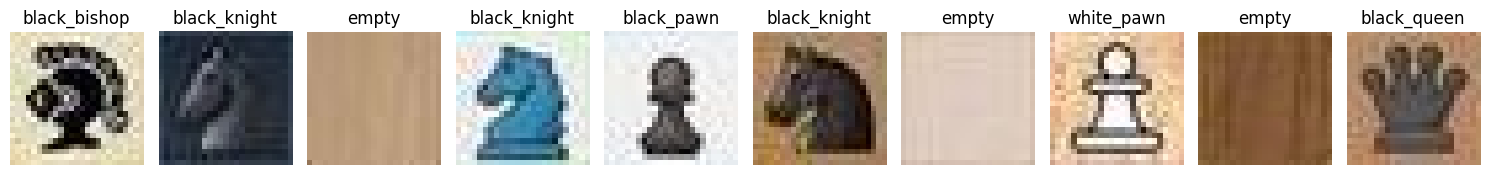

In [ ]:
#Display 10 Random images
# Pick 5 random indices from the training set
random_indices = np.random.choice(len(X_train), 10, replace=False)

# Create a figure with 5 subplots
fig, axes = plt.subplots(1, 10, figsize=(15, 3))

for i, idx in enumerate(random_indices):
    # Get the flattened image array and its label
    flat_img = X_train[idx]
    label = y_train[idx]

    # Reshape the 1D array (1875,) back to (25, 25, 3)
    # We cast to uint8 so matplotlib knows these are standard 0-255 pixel values
    img_reshaped = flat_img.reshape(25, 25, 3).astype(np.uint8)

    # Display the image and label
    axes[i].imshow(img_reshaped)
    axes[i].set_title(label)
    axes[i].axis('off') # Hides the axis grid numbers

plt.tight_layout()
plt.show()

In [ ]:
# Normalize the pixel values to be between 0.0 and 1.0
print("Normalizing data...")
X_train_norm = X_train / 255.0
X_test_norm = X_test / 255.0


Normalizing data...


In [ ]:
# Initialize Logistic Regression with max_iter
MAX_ITER = 200
print(f"Initializing Logistic Regression with max_iter={MAX_ITER}...")
log_reg = LogisticRegression(max_iter=MAX_ITER, random_state=42)

# Train the model on the normalized training data
start_time = time.time()
log_reg.fit(X_train_norm, y_train)
end_time = time.time()

print("Logistic Regression model trained successfully!")
print(f"Training took {end_time - start_time:.2f} seconds.")

Initializing Logistic Regression with max_iter=200...
Logistic Regression model trained successfully!
Training took 314.15 seconds.


Predictions and Probabilities calculated in 0.56 seconds.
Test Accuracy Score: 0.9995
Test Log Loss: 0.0046


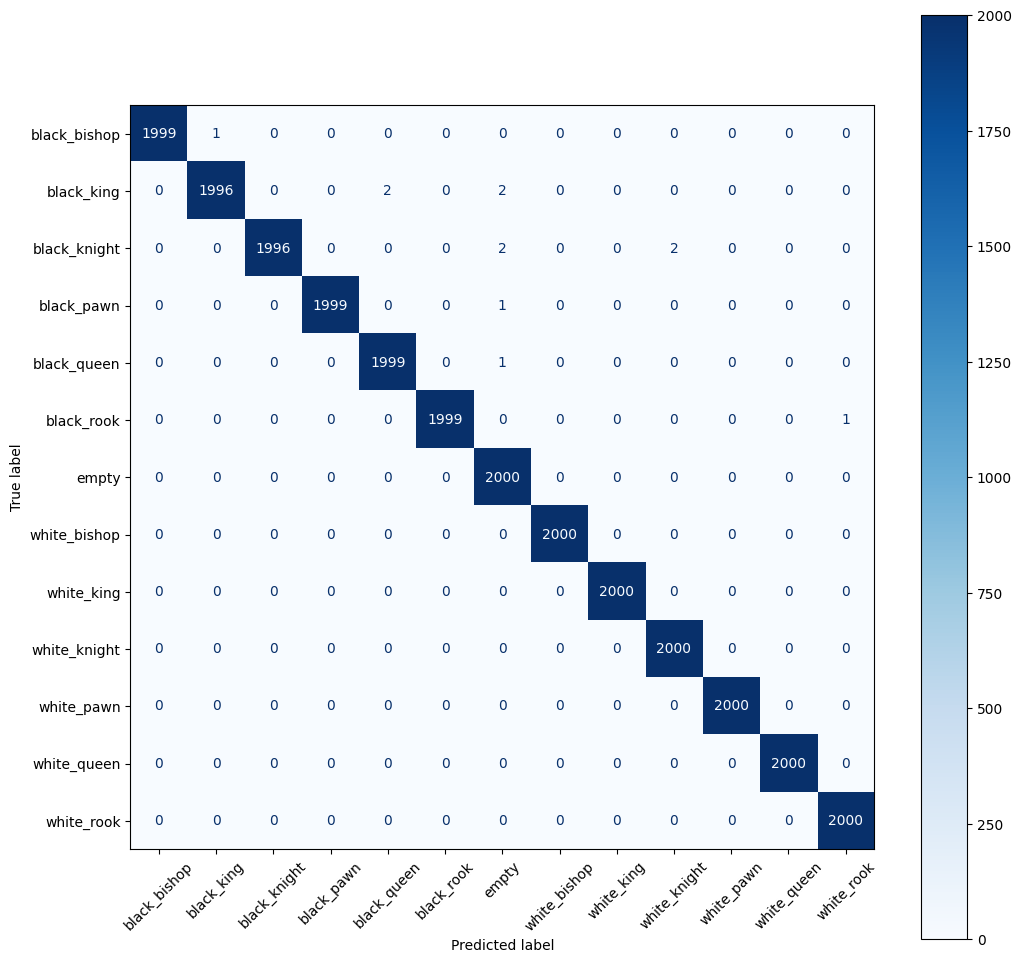

In [ ]:
# 1. Predictions and Probabilities
start_time = time.time()
y_pred = log_reg.predict(X_test_norm)
y_proba = log_reg.predict_proba(X_test_norm)
end_time = time.time()

print(f"Predictions and Probabilities calculated in {end_time - start_time:.2f} seconds.")

# a. Accuracy Score
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy Score: {acc:.4f}")

# b. Log Loss
loss = log_loss(y_test, y_proba)
print(f"Test Log Loss: {loss:.4f}")

# c. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(12, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=log_reg.classes_)
disp.plot(cmap='Blues', ax=ax, xticks_rotation=45)

Now, let's train a k-Nearest Neighbors classifier Model with k=5
==========================================================

In [ ]:
print("Training k-NN classifier...")
start_time = time.time()
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_norm, y_train)
end_time = time.time()
print(f"KNN Model Training took {end_time - start_time:.2f} seconds.")


Training k-NN classifier...
KNN Model Training took 0.28 seconds.


Now, let's train a Random Forest Classifier Model with n_estimators=100
==================================================================

In [ ]:
print("Training Random Forest classifier...")
start_time = time.time()
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_norm, y_train)
end_time = time.time()
print(f"Random Forest Classifier Model Training took {end_time - start_time:.2f} seconds.")

Training Random Forest classifier...
Random Forest Classifier Model Training took 512.49 seconds.


Now an SVM Model
=================

In [ ]:
print("Training Support Vector Machine classifier...")
start_time = time.time()

# Initialize SVM (using RBF kernel by default)
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_norm, y_train)

end_time = time.time()
print(f"SVM Model Training took {end_time - start_time:.2f} seconds.")

Training Support Vector Machine classifier...
SVM Model Training took 1064.63 seconds.


Now let's use a Boosting Model
==============================

Note on Boosting Algorithms: While Random Forest algorithm builds 100s of decision trees independently in parallel and takes a majority vote, Boosting models trains decision trees sequentially - each new stage builds on top of the previous one by looking and the mistakes made by the previous step and rectifying , progressively.

A Note on the choice of the Boosting Algorithm used here:  It appears that there are many (100s??) of Boosting Algorigtms, and knowing & contrasting them to pick one is a difficult choice given the time constraints.  So took the help of Gemini , describing my large dataset, to recommend an appropriate Boosting Algorithm.  It did not take long for Gemini to recommend HistGradientBoostingClassifier. It appears for datasets that are larger than 10K samples, HistGradientBoostingClassifier is an automatic choice!!     

In [ ]:
print("Training Histogram Gradient Boosting Classifier...")
start_time = time.time()

# Initialize and train the boosting model
# random_state=42 ensures reproducibility
boost_model = HistGradientBoostingClassifier(random_state=42)
boost_model.fit(X_train_norm, y_train)

end_time = time.time()
print(f"Boosting Model Training took {end_time - start_time:.2f} seconds.")

# Calculate grid-level test accuracy for consistency
y_pred_boost = boost_model.predict(X_test_norm)
from sklearn.metrics import accuracy_score
acc_boost = accuracy_score(y_test, y_pred_boost)
print(f"Boosting Test Accuracy (Grid-level): {acc_boost:.4f}")

Training Histogram Gradient Boosting Classifier...
Boosting Model Training took 2154.73 seconds.
Boosting Test Accuracy (Grid-level): 1.0000


Now, let's compare the Accuracy of the Models so far
=======================================================

In [ ]:
# 2. Predict and calculate test accuracies for all three models
start_time = time.time()
y_pred_log = log_reg.predict(X_test_norm)
end_time = time.time()
log_reg_pred_time = end_time - start_time
print(f"Logistic Regression Predictions calculated in {log_reg_pred_time:.2f} seconds.")

start_time = time.time()
y_pred_knn = knn.predict(X_test_norm)
y_pred_rf = rf.predict(X_test_norm)
end_time = time.time()
knn_pred_time = end_time - start_time
print(f"K-NN Predictions calculated in {knn_pred_time:.2f} seconds.")

# Predict using the SVM model
start_time = time.time()
y_pred_svm = svm_model.predict(X_test_norm)
end_time = time.time()
svm_pred_time = end_time - start_time

print(f"SVM Predictions calculated in {svm_pred_time:.2f} seconds.")

acc_log = accuracy_score(y_test, y_pred_log)
acc_knn = accuracy_score(y_test, y_pred_knn)
acc_rf = accuracy_score(y_test, y_pred_rf)
acc_svm = accuracy_score(y_test, y_pred_svm)

print(f"\nTest Accuracies:")
print(f"Logistic Regression: {acc_log:.4f}")
print(f"k-NN (k=5):          {acc_knn:.4f}")
print(f"Random Forest:       {acc_rf:.4f}")
print(f"SVM Test Accuracy: {acc_svm:.4f}")

Logistic Regression Predictions calculated in 0.34 seconds.
K-NN Predictions calculated in 553.42 seconds.
SVM Predictions calculated in 689.02 seconds.

Test Accuracies:
Logistic Regression: 0.9995
k-NN (k=5):          0.9995
Random Forest:       1.0000
SVM Test Accuracy: 0.9998


NOTE: Observed the training time and prediction time for the K-NN. The training hardly takes any time as the 'trining' is imply recording all the dataset; but prediction / inferencing is where K-NN needs to spend time calculating the nearest neignbors and predicting , implying that in K-NN you pay a price at the time of inferencing!!



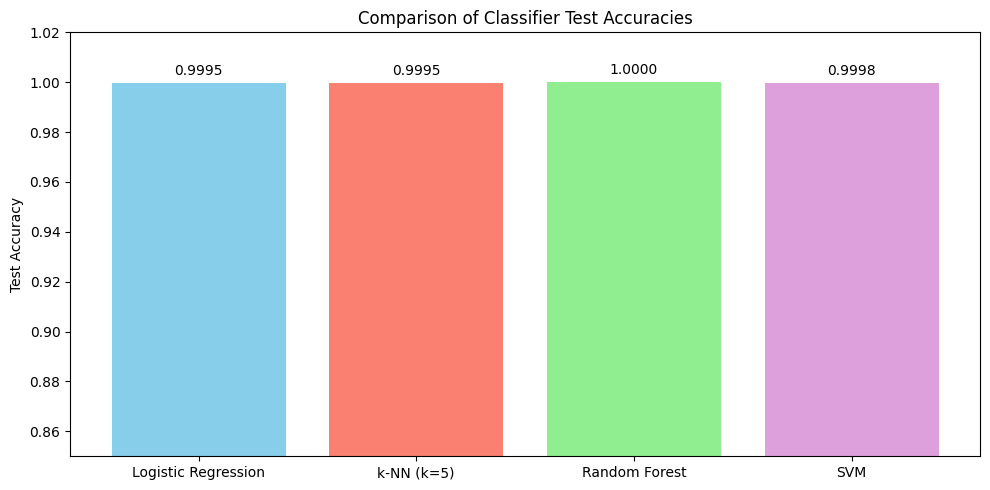

In [ ]:
# Create a bar chart comparing test accuracies
models = ['Logistic Regression', 'k-NN (k=5)', 'Random Forest', 'SVM']
accuracies = [acc_log, acc_knn, acc_rf, acc_svm]

plt.figure(figsize=(10, 5)) # Slightly wider figure to accommodate the 4th bar
bars = plt.bar(models, accuracies, color=['skyblue', 'salmon', 'lightgreen', 'plum'])
plt.ylim(0.85, 1.02)  # Zoom in on the high accuracy range
plt.ylabel('Test Accuracy')
plt.title('Comparison of Classifier Test Accuracies')

# Add accuracy text labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.002, f"{yval:.4f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()

==========================================================

Inferencing Section
====================

Here, we take the Chess-Board images that were unused during the Training (or during testing post training), and run the inference. We break the image into 64 squares grid and run inference; from the inference, we construct the FEN sequence for the board, and compare it against the Label FEN for that image.  We do this for N images and gather the  Chess-Board level accuracy in predicting the correct FEN by the models.

In [ ]:
!unzip -q "/content/drive/MyDrive/Stanford-Courses/Python-Tech27-AIML-July2026/Unused-Downsized-Dataset-200-From-10K-2K.zip" -d "/content/Unused-Full-Boards"

replace /content/Unused-Full-Boards/Unused-Downsized-Dataset-200/test/5N2-6Q1-8-3b4-Kp1k2p1-2b5-7P-3Q4.jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


In [ ]:
INFERENCE_FULL_BOARD_TEST_DIR = "/content/Unused-Full-Boards/Unused-Downsized-Dataset-200/test"

In [ ]:
!ls {INFERENCE_FULL_BOARD_TEST_DIR} | head -n 5

1b1b2k1-K2B1q2-R3B2p-3b1NR1-5p2-3N4-8-5N2.jpeg
1b1B4-1p4P1-5k2-1n3q2-8-2B5-1K3rR1-2q5.jpeg
1b1B4-2b3PK-7P-8-1BP4k-4P3-8-8.jpeg
1b1B4-3b1PPn-8-6b1-n2R3r-2K5-8-3Rk3.jpeg
1b1b4-Kn6-2Pk4-8-5p2-7n-7n-8.jpeg


In [ ]:
# --- MAPPING DICTIONARIES ---
# Maps standard FEN characters to your training folder class names
CHAR_TO_LABEL = {
    'P': 'white_pawn', 'N': 'white_knight', 'B': 'white_bishop',
    'R': 'white_rook', 'Q': 'white_queen', 'K': 'white_king',
    'p': 'black_pawn', 'n': 'black_knight', 'b': 'black_bishop',
    'r': 'black_rook', 'q': 'black_queen', 'k': 'black_king'
}

# Reverse mapping for reconstructing the FEN
LABEL_TO_CHAR = {v: k for k, v in CHAR_TO_LABEL.items()}
LABEL_TO_CHAR['empty'] = 'empty' # Special handling for empty squares


# --- HELPERS ---

def fen_to_labels(fen_string):
    """Converts a FEN string into a list of 64 exact class labels."""
    labels = []
    # The filenames use '-' instead of standard '/' for rows, so we replace them
    fen_string = fen_string.replace('-', '')
    fen_string = fen_string.replace('/', '')

    for char in fen_string:
        if char.isdigit():
            # If it is a number, add that many 'empty' labels
            labels.extend(['empty'] * int(char))
        else:
            # If it is a piece, look up its full label name
            labels.append(CHAR_TO_LABEL[char])

    return labels


def labels_to_fen(labels_array):
    """Compresses an array of 64 predicted labels back into a hyphen-separated FEN string."""
    fen_rows = []

    # Process the board row by row (8 squares at a time)
    for i in range(0, 64, 8):
        row_labels = labels_array[i:i+8]
        row_fen = ""
        empty_count = 0

        for label in row_labels:
            if label == 'empty':
                empty_count += 1
            else:
                if empty_count > 0:
                    row_fen += str(empty_count)
                    empty_count = 0
                row_fen += LABEL_TO_CHAR[label]

        if empty_count > 0:
            row_fen += str(empty_count)

        fen_rows.append(row_fen)

    # Join the 8 rows with the hyphen separator to match filenames perfectly
    return "-".join(fen_rows)


def process_board_image(image_path):
    """
    Slices a 200x200 board into 64 normalized 1D arrays.
    Returns: X_batch_normalized (64, 1875), y_true_labels (64,), true_fen (string)
    """
    # 1. Extract the true FEN directly from the filename (keeping the '-')
    filename = os.path.basename(image_path)
    true_fen, _ = os.path.splitext(filename)

    # 2. Get the 64 ground-truth text labels
    y_true_labels = np.array(fen_to_labels(true_fen))

    # 3. Load and slice the image
    img = Image.open(image_path).convert('RGB')
    img_array = np.array(img)

    X_batch = []
    square_size = 25

    for row in range(8):
        for col in range(8):
            # Calculate pixel coordinates for the slice
            y_start = row * square_size
            y_end = y_start + square_size
            x_start = col * square_size
            x_end = x_start + square_size

            # Extract the 25x25x3 square
            square = img_array[y_start:y_end, x_start:x_end]

            # Flatten to 1D (1875,) and append
            X_batch.append(square.flatten())

    # 4. Convert to numpy array and normalize!
    X_batch = np.array(X_batch)
    X_batch_normalized = X_batch / 255.0

    return X_batch_normalized, y_true_labels, true_fen

In [ ]:
# Quick Test

base_test_dir = INFERENCE_FULL_BOARD_TEST_DIR

# Grab the first jpeg file we find programmatically
sample_files = [f for f in os.listdir(base_test_dir) if f.endswith(('.jpeg', '.jpg'))]
test_image = os.path.join(base_test_dir, sample_files[0])

print(f"Testing with file: {test_image}\n")

# Run the processor
X_batch, y_true, true_fen = process_board_image(test_image)

print(f"X_batch shape: {X_batch.shape} (Should be 64, 1875)")
print(f"y_true shape: {y_true.shape} (Should be 64,)")
print(f"True FEN: {true_fen}")
print(f"Reconstructed FEN from labels: {labels_to_fen(y_true)}")

Testing with file: /content/Unused-Full-Boards/Unused-Downsized-Dataset-200/test/8-1qp3k1-1b6-1R6-4b1b1-4P3-7P-5K2.jpeg

X_batch shape: (64, 1875) (Should be 64, 1875)
y_true shape: (64,) (Should be 64,)
True FEN: 8-1qp3k1-1b6-1R6-4b1b1-4P3-7P-5K2
Reconstructed FEN from labels: 8-1qp3k1-1b6-1R6-4b1b1-4P3-7P-5K2


In [ ]:

# EVALUATION LOOP

def evaluate_models(target_dir, models_dict, max_boards=100):
    results = {
        name: {
            'total_squares': 0, 'correct_squares': 0,
            'total_boards': 0, 'correct_boards': 0,
            'time_taken': 0.0,
            'all_y_true': [], # <-- NEW: Stores every true label
            'all_y_pred': []  # <-- NEW: Stores every predicted label
        } for name in models_dict.keys()
    }

    image_files = [f for f in os.listdir(target_dir) if f.endswith(('.jpeg', '.jpg', '.png'))]
    if max_boards is not None:
        image_files = image_files[:max_boards]

    total_processed = len(image_files)
    print(f"Starting evaluation on {total_processed} full boards...")

    for idx, filename in enumerate(image_files):
        filepath = os.path.join(target_dir, filename)
        X_batch, y_true, true_fen = process_board_image(filepath)

        for model_name, model in models_dict.items():
            start_time = time.time()
            y_pred = model.predict(X_batch)
            pred_fen = labels_to_fen(y_pred)
            results[model_name]['time_taken'] += (time.time() - start_time)

            # --- NEW: Save predictions for advanced metrics ---
            results[model_name]['all_y_true'].extend(y_true)
            results[model_name]['all_y_pred'].extend(y_pred)

            results[model_name]['correct_squares'] += np.sum(y_pred == y_true)
            results[model_name]['total_squares'] += 64
            results[model_name]['total_boards'] += 1
            if pred_fen == true_fen:
                results[model_name]['correct_boards'] += 1

        if (idx + 1) % 10 == 0 or (idx + 1) == total_processed:
            print(f"Processed {idx + 1}/{total_processed} boards...")

    for name in models_dict.keys():
        res = results[name]
        res['square_accuracy'] = res['correct_squares'] / res['total_squares']
        res['board_accuracy'] = res['correct_boards'] / res['total_boards']

    print("\nEvaluation complete!")
    return results

In [ ]:
# Dictionary mapping your desired display names to your trained model variables
my_models = {
    'Logistic Regression': log_reg,
    'k-NN (k=5)': knn,
    'Random Forest': rf,
    'SVM': svm_model,
    'Gradient Boosting': boost_model
}

# Run the evaluation! (Limiting to 100 boards for a quick initial test)
# Pass max_boards=None to run on all 5000 images
evaluation_results = evaluate_models(INFERENCE_FULL_BOARD_TEST_DIR, my_models, max_boards=200)

# Quick print of the raw results dictionary
print("\nRaw Results:")
for model, metrics in evaluation_results.items():
    print(f"\n{model}:")
    print(f"  Square Accuracy: {metrics['square_accuracy']:.4f}")
    print(f"  Exact FEN Accuracy: {metrics['board_accuracy']:.4f}")

Starting evaluation on 200 full boards...
Processed 10/200 boards...
Processed 20/200 boards...
Processed 30/200 boards...
Processed 40/200 boards...
Processed 50/200 boards...
Processed 60/200 boards...
Processed 70/200 boards...
Processed 80/200 boards...
Processed 90/200 boards...
Processed 100/200 boards...
Processed 110/200 boards...
Processed 120/200 boards...
Processed 130/200 boards...
Processed 140/200 boards...
Processed 150/200 boards...
Processed 160/200 boards...
Processed 170/200 boards...
Processed 180/200 boards...
Processed 190/200 boards...
Processed 200/200 boards...

Evaluation complete!

Raw Results:

Logistic Regression:
  Square Accuracy: 0.9998
  Exact FEN Accuracy: 0.9950

k-NN (k=5):
  Square Accuracy: 1.0000
  Exact FEN Accuracy: 1.0000

Random Forest:
  Square Accuracy: 1.0000
  Exact FEN Accuracy: 1.0000

SVM:
  Square Accuracy: 1.0000
  Exact FEN Accuracy: 1.0000

Gradient Boosting:
  Square Accuracy: 1.0000
  Exact FEN Accuracy: 1.0000


In [ ]:
# VISUALIZER ---

def display_metrics(results):
    """
    Generates side-by-side bar charts comparing Square Accuracy, Exact Board Accuracy, and Inference Time.
    """
    models = list(results.keys())
    square_accs = [results[m]['square_accuracy'] for m in models]
    board_accs = [results[m]['board_accuracy'] for m in models]

    # Extract the total inference time for each model
    inference_times = [results[m]['time_taken'] for m in models]

    # Create a figure with 3 subplots side-by-side (made slightly wider to fit the 3rd chart)
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
    colors = ['skyblue', 'salmon', 'lightgreen', 'plum']

    # --- Chart 1: Square-Level Accuracy ---
    bars1 = ax1.bar(models, square_accs, color=colors)
    ax1.set_title('Square-Level Accuracy', fontsize=14)
    ax1.set_ylabel('Accuracy')

    min_sq = min(square_accs)
    ax1.set_ylim(max(0, min_sq - 0.05), 1.05)

    for bar in bars1:
        yval = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2.0, yval + 0.005, f"{yval:.4f}", ha='center', va='bottom', fontsize=11)

    # --- Chart 2: Exact Board (FEN) Accuracy ---
    bars2 = ax2.bar(models, board_accs, color=colors)
    ax2.set_title('Exact Board (FEN) Accuracy', fontsize=14)
    ax2.set_ylabel('Accuracy')
    ax2.set_ylim(0, 1.1)

    for bar in bars2:
        yval = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2.0, yval + 0.015, f"{yval:.4f}", ha='center', va='bottom', fontsize=11)

    # --- Chart 3: Total Inference Time ---
    bars3 = ax3.bar(models, inference_times, color=colors)
    ax3.set_title('Total Inference Time (Seconds)', fontsize=14)
    ax3.set_ylabel('Seconds')

    # Add some dynamic headroom based on the slowest model
    max_time = max(inference_times)
    # Handle the edge case where inference was so fast it registered as 0.0
    if max_time == 0: max_time = 0.1
    ax3.set_ylim(0, max_time * 1.15)

    for bar in bars3:
        yval = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2.0, yval + (max_time * 0.02), f"{yval:.3f}s", ha='center', va='bottom', fontsize=11)

    plt.tight_layout()
    plt.show()

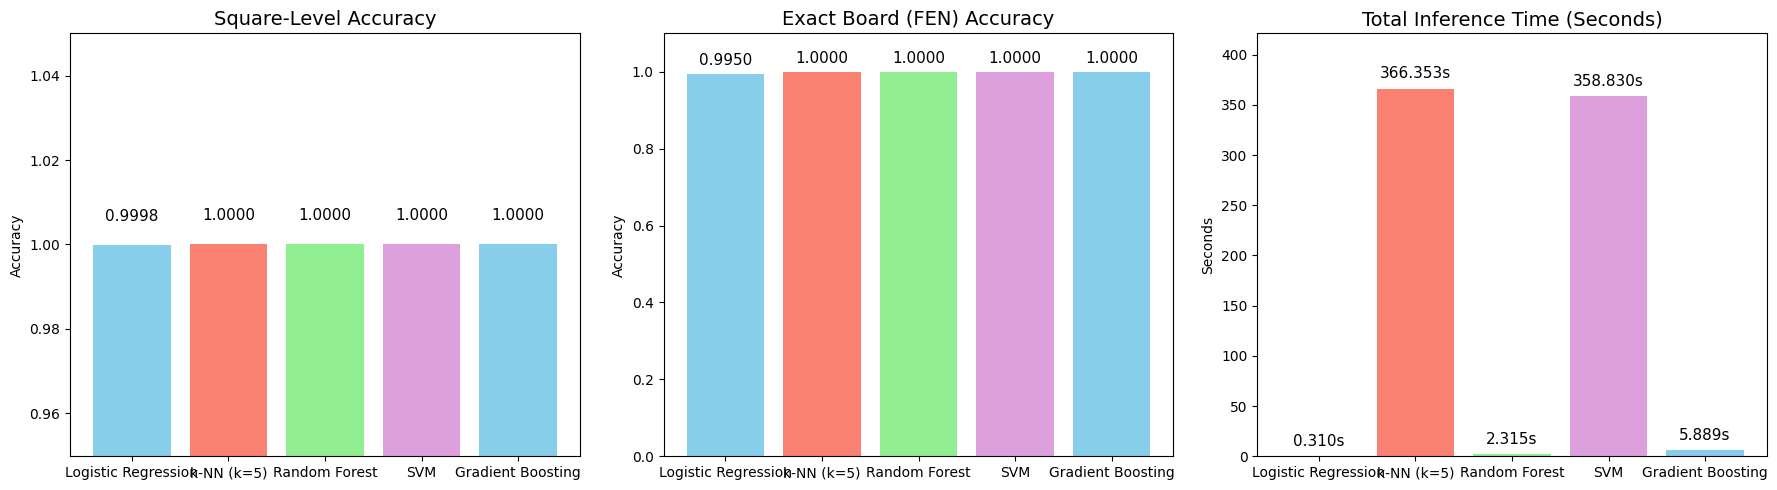

In [ ]:
# Call the visualizer with the results from Module 2
display_metrics(evaluation_results)

In [ ]:
def display_advanced_metrics(results):
    for model_name, data in results.items():
        print(f"\n" + "="*50)
        print(f"MODEL: {model_name}")
        print("="*50)

        # 1. Precision, Recall, and F1-Score
        print("\nCLASSIFICATION REPORT:")
        print(classification_report(data['all_y_true'], data['all_y_pred']))

        # 2. Confusion Matrix
        print("\nCONFUSION MATRIX:")
        cm = confusion_matrix(data['all_y_true'], data['all_y_pred'])

        # We extract the unique labels that actually appeared in the test set to label the axes
        unique_labels = np.unique(data['all_y_true'])

        fig, ax = plt.subplots(figsize=(10, 10))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=unique_labels)

        # Plot with 45-degree angled text so the 13 piece names don't overlap
        disp.plot(cmap='Blues', ax=ax, xticks_rotation=45)
        plt.title(f'Confusion Matrix: {model_name}')
        plt.tight_layout()
        plt.show()


MODEL: Logistic Regression

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

black_bishop       1.00      1.00      1.00       161
  black_king       1.00      0.99      1.00       200
black_knight       1.00      0.99      1.00       150
  black_pawn       1.00      1.00      1.00       143
 black_queen       1.00      1.00      1.00        62
  black_rook       1.00      1.00      1.00       130
       empty       1.00      1.00      1.00     11075
white_bishop       1.00      1.00      1.00       159
  white_king       1.00      1.00      1.00       200
white_knight       1.00      1.00      1.00       154
  white_pawn       1.00      1.00      1.00       141
 white_queen       1.00      1.00      1.00        64
  white_rook       1.00      1.00      1.00       161

    accuracy                           1.00     12800
   macro avg       1.00      1.00      1.00     12800
weighted avg       1.00      1.00      1.00     12800


CONFUSION MATRIX:


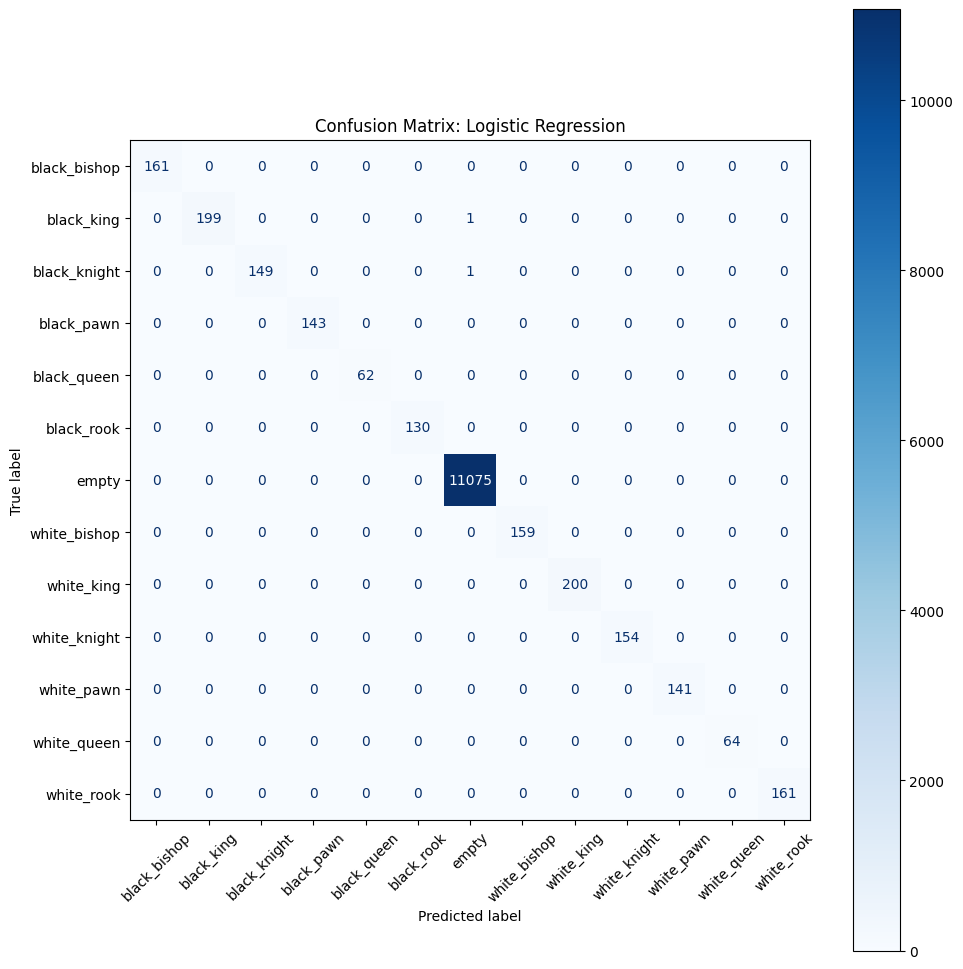


MODEL: k-NN (k=5)

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

black_bishop       1.00      1.00      1.00       161
  black_king       1.00      1.00      1.00       200
black_knight       1.00      1.00      1.00       150
  black_pawn       1.00      1.00      1.00       143
 black_queen       1.00      1.00      1.00        62
  black_rook       1.00      1.00      1.00       130
       empty       1.00      1.00      1.00     11075
white_bishop       1.00      1.00      1.00       159
  white_king       1.00      1.00      1.00       200
white_knight       1.00      1.00      1.00       154
  white_pawn       1.00      1.00      1.00       141
 white_queen       1.00      1.00      1.00        64
  white_rook       1.00      1.00      1.00       161

    accuracy                           1.00     12800
   macro avg       1.00      1.00      1.00     12800
weighted avg       1.00      1.00      1.00     12800


CONFUSION MATRIX:


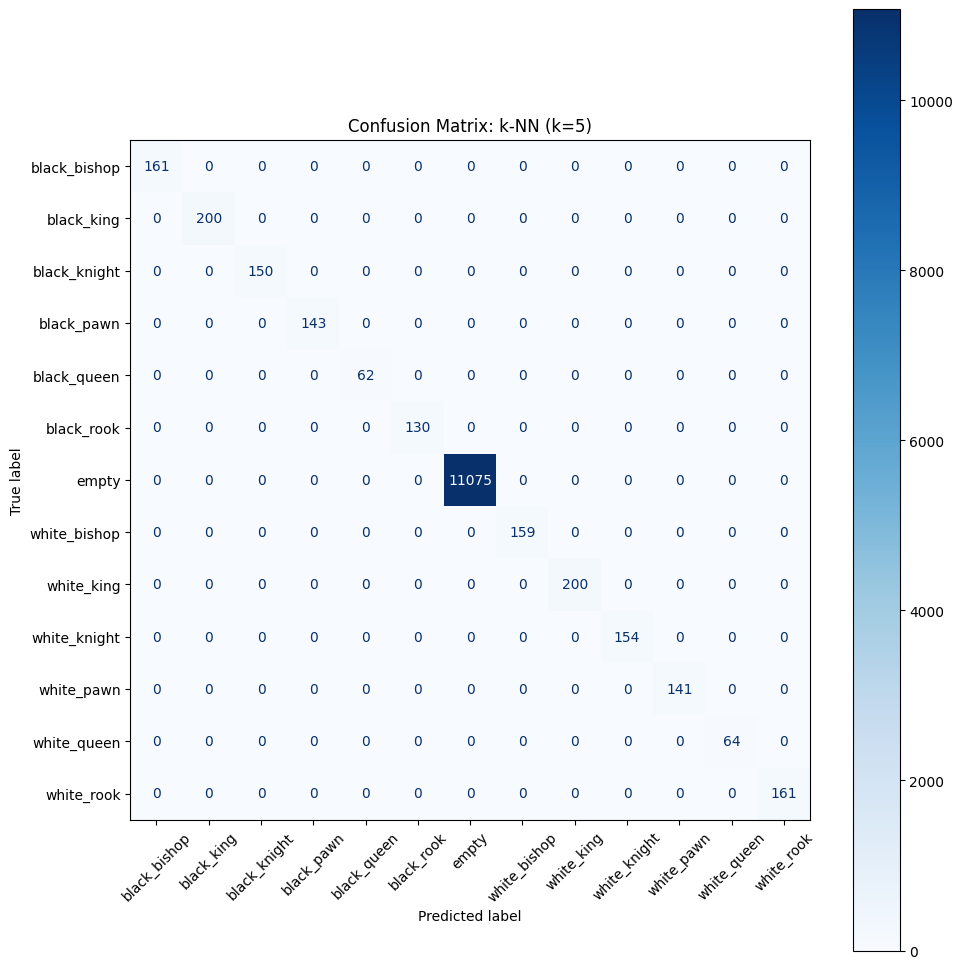


MODEL: Random Forest

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

black_bishop       1.00      1.00      1.00       161
  black_king       1.00      1.00      1.00       200
black_knight       1.00      1.00      1.00       150
  black_pawn       1.00      1.00      1.00       143
 black_queen       1.00      1.00      1.00        62
  black_rook       1.00      1.00      1.00       130
       empty       1.00      1.00      1.00     11075
white_bishop       1.00      1.00      1.00       159
  white_king       1.00      1.00      1.00       200
white_knight       1.00      1.00      1.00       154
  white_pawn       1.00      1.00      1.00       141
 white_queen       1.00      1.00      1.00        64
  white_rook       1.00      1.00      1.00       161

    accuracy                           1.00     12800
   macro avg       1.00      1.00      1.00     12800
weighted avg       1.00      1.00      1.00     12800


CONFUSION MATRIX:


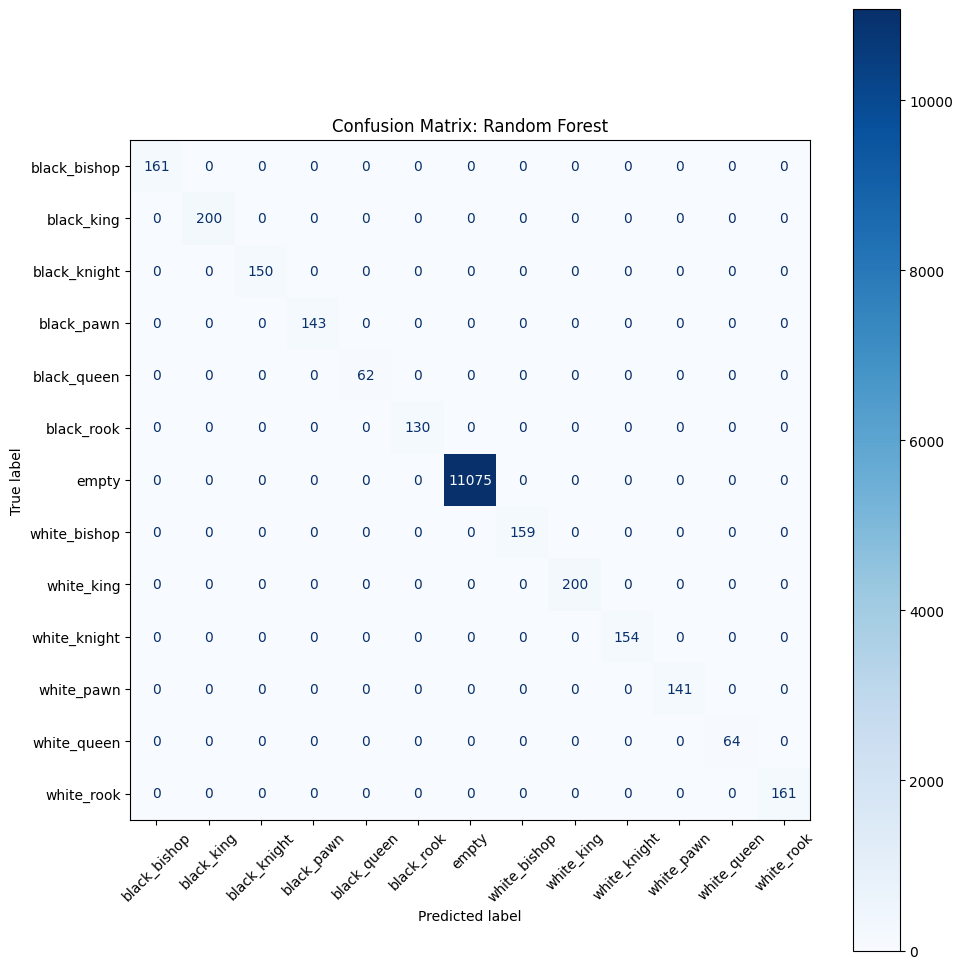


MODEL: SVM

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

black_bishop       1.00      1.00      1.00       161
  black_king       1.00      1.00      1.00       200
black_knight       1.00      1.00      1.00       150
  black_pawn       1.00      1.00      1.00       143
 black_queen       1.00      1.00      1.00        62
  black_rook       1.00      1.00      1.00       130
       empty       1.00      1.00      1.00     11075
white_bishop       1.00      1.00      1.00       159
  white_king       1.00      1.00      1.00       200
white_knight       1.00      1.00      1.00       154
  white_pawn       1.00      1.00      1.00       141
 white_queen       1.00      1.00      1.00        64
  white_rook       1.00      1.00      1.00       161

    accuracy                           1.00     12800
   macro avg       1.00      1.00      1.00     12800
weighted avg       1.00      1.00      1.00     12800


CONFUSION MATRIX:


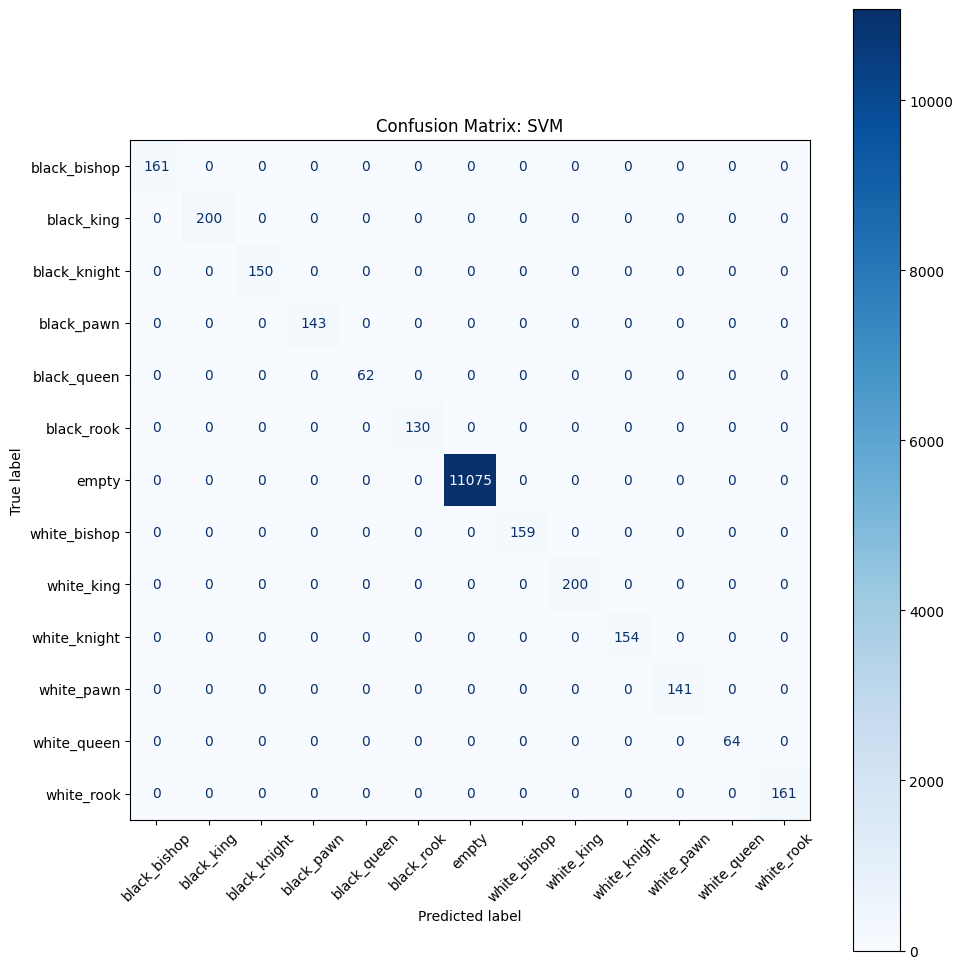


MODEL: Gradient Boosting

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

black_bishop       1.00      1.00      1.00       161
  black_king       1.00      1.00      1.00       200
black_knight       1.00      1.00      1.00       150
  black_pawn       1.00      1.00      1.00       143
 black_queen       1.00      1.00      1.00        62
  black_rook       1.00      1.00      1.00       130
       empty       1.00      1.00      1.00     11075
white_bishop       1.00      1.00      1.00       159
  white_king       1.00      1.00      1.00       200
white_knight       1.00      1.00      1.00       154
  white_pawn       1.00      1.00      1.00       141
 white_queen       1.00      1.00      1.00        64
  white_rook       1.00      1.00      1.00       161

    accuracy                           1.00     12800
   macro avg       1.00      1.00      1.00     12800
weighted avg       1.00      1.00      1.00     12800


CONFUSION MATRIX:


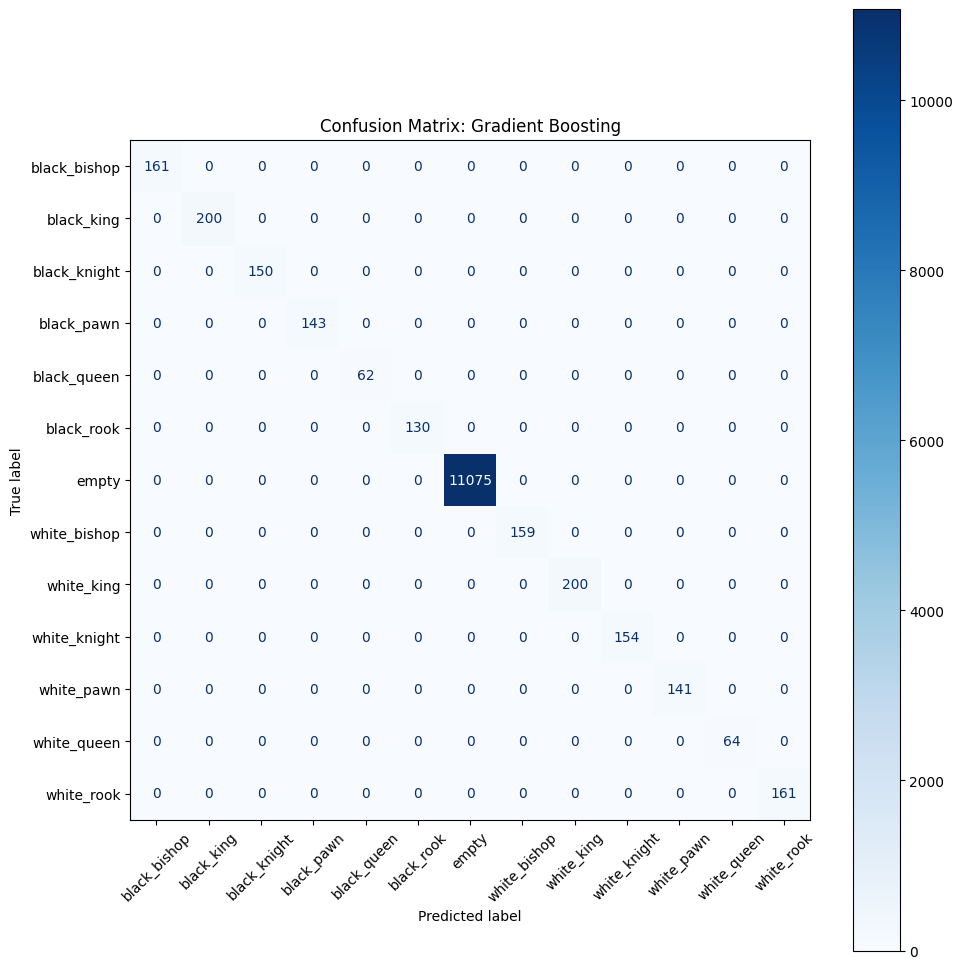

In [ ]:
display_advanced_metrics(evaluation_results)

Notes and Observations:
Hmmm, I'm getting 100% accuracy from all the models!!  I did check during model training if there's any overfitting, but since they did pretty well on the test data, it does not look like there's any overfitting here.

Also, it's to be noted that a Chess-board when fully loaded as 32 squares occupied, and 32 empty, and out of 32 occupied, 16 are pawns; so if a model predicted all squares as empty, it's still 50% accurate - this is just tossing a coin to hit 50% accuracy!!

One possibility of why this high accuracy could be due to quality of dataset.  I observed that the dataset itself is genenrated using a script and it looks almost perfect.  A real world pic would be containing shadows, blur, etc that might throw off these models, but not on the synthetic dataset that I'm using from Kaggle!!

This demonstrates that for perfectly clean images, the traditional ML models like Logistic-Regression, KNN, Random-Forest, and SVMs are sufficient, and we dont necessarily need complex models like CNNs.  However, in real-world, the data that we need to run inference on is hardly perfect!!

One other observation is that, even within these models, looking at the time taken for inference, we can see that KNN and SVM have a high penulty at the time of inference - something to be acutely aware of when selecting a right model for production use.
